# DS 3025 Project 4: Neural Network From Scratch


**Name:** Mackenzie Kleczynski etm8nu

**Type the Honor Pledge Here:** On my honor as a student, I have neither given nor received unauthorized aid on this assignment/examination

In this project, you will build a neural network from scratch and use it to practice evidence-based model comparison.

This project has two main goals:

1. **Understand neural network training**
   - Build the core pieces of a neural network yourself
   - See how forward propagation, backpropagation, and gradient-based updates work together

2. **Practice structured experimentation**
   - Compare models using evidence
   - Document what you changed, what happened, and what you learned

## Project roadmap

You will complete the project in six parts:

- **Part 1:** Build and verify a **1-hidden-layer** neural network
- **Part 2:** Extend that model into a **2-hidden-layer** neural network
- **Part 3:** Run structured experiments on the **2-hidden-layer** model
- **Part 4:** Document **6 experimental runs** in a tuning log
- **Part 5:** Defend your best model using evidence
- **Part 6:** Answer short comprehension questions

## Project expectations

Most of your grade comes from:
- correct implementation
- clear reasoning
- disciplined experimentation
- evidence-based interpretation

The hidden model-ranking component is worth **10 points out of 100**. It matters, but it does **not** dominate the project.

To keep grading fair and reproducible, please follow these rules throughout the notebook:

- Use **seed = 42** everywhere.
- Do **not** edit cells marked **DO NOT EDIT**.
- Do **not** rename the function headers provided in the notebook.
- Build only from the code and imports already provided.
- Do **not** add features, columns, outside data, or your own test set.
- Your final ranked model must be reported in the **final configuration dictionary** near the end of the notebook.
- Your final ranked model must match **one of your 6 logged runs** from Part 4.
- If the final configuration dictionary is missing, malformed, or does not match one of your 6 logged runs, you will receive **0/10** for the ranking component.

Before submitting, restart your Colab runtime and run the notebook from top to bottom. Your submitted results should be reproducible.

## How to think about model evaluation

In this project, you will track both **cost** and **accuracy**.

- **Accuracy** tells you how often the model predicts the correct class.
- **Cost** tells you how wrong the model’s predictions are numerically on average.

These two metrics are related, but they are not identical, so both are useful when evaluating training.

The output node predicts the probability of **white wine**, because the code uses `red = 0` and `white = 1`.

## Code guide

A few notebook cells are intentionally protected so grading stays reproducible.

- Cells labeled **DO NOT EDIT** should be left unchanged.
- Keep the function headers exactly as written. You should fill in the body of each function, not rename it.
- In this notebook, the `test()` and `test_2()` functions should **return numeric accuracy values** so they can be reused in analysis and grading.
- In **Part 3** and **Part 4**, your main evaluation metrics are:
  - **final train cost**
  - **final test cost**
  - **test accuracy**
  - **runtime**
- For your **final best model**, you should also compare **train accuracy** and **test accuracy** so you can comment on possible overfitting.
- In **Part 4**, you must document **6 runs** in the markdown log. You may do additional private runs, but your final submitted model must be one of the 6 documented runs.


### Tips for Success on This Project

- Use `print()` statements strategically to debug shapes, intermediate outputs, and final metrics.
- Build and test small helper functions first before trying to run the full training loop.
- Check matrix shapes carefully before matrix multiplication. If something is not working, print `.shape` and verify that your dimensions line up. In some cases, you may need to transpose with `.T`.
- If your results look very different from what you expect, first check:
  - your random seed
  - your matrix shapes
  - your averaging/division steps for cost and gradients
  - whether you used the correct training data inside `train()` and `train_2()`
- Use the structured baseline runs in the notebook as debugging checkpoints before moving on to experiments.
- The `test()` and `test_2()` functions should return numeric accuracy values so you can reuse them in tables, comparisons, and final evaluation.
- Make sure your cost tracking matches the notebook instructions. In this project, you should report train and test curves on an **MSE scale**, so be careful about when you divide by the number of examples.
- Use the experiment log in Part 4 to stay organized. Document what you changed, what happened, and what you learned after each run.
- If you get stuck on Python syntax or an error message, look it up. Debugging is part of the project.

In [1]:

#### DO NOT EDIT ####
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time

In [2]:

#### DO NOT EDIT ####
seed = 42
np.random.seed(seed)

## Load Data

For this project, we're using a new dataset to classify wine type between red and white. We have the following measurements of each wine "subject" (`fixed acidity`, `volatile acidity`, `residual sugar`, `chlorides`, `alcohol`, `quality`).

Our goal is to predict the type of wine (red or white). This means we are dealing with a binary classification problem. Below is the code to load in the data sets to X and Y. Do **not** change the code below.

### Important note
In this project:
- red wine = 0
- white wine = 1

So the output node should be interpreted as the model's estimate that an example is **white wine**.


In [3]:

#### DO NOT EDIT ####
red = pd.read_csv(
    'https://raw.githubusercontent.com/shrikant-temburwar/Wine-Quality-Dataset/refs/heads/master/winequality-red.csv',
    sep=';'
)
white = pd.read_csv(
    'https://raw.githubusercontent.com/shrikant-temburwar/Wine-Quality-Dataset/refs/heads/master/winequality-white.csv',
    sep=';'
)

# Use the same reduced sample as the original project
red = red.sample(200, random_state=seed).copy()
white = white.sample(200, random_state=seed).copy()

# Keep the same six-feature setup
drop_cols = ['density', 'pH', 'citric acid', 'free sulfur dioxide', 'total sulfur dioxide', 'sulphates']
red.drop(drop_cols, axis=1, inplace=True)
white.drop(drop_cols, axis=1, inplace=True)

# add columns for classification
red['type'] = 0
white['type'] = 1

# combine the data frames
wine = pd.concat([red, white], axis=0).sample(frac=1, random_state=seed).reset_index(drop=True)

# Now separate X and Y
X = wine.drop(columns=['type'])
Y = wine['type']

print(X.head())
print(Y.value_counts())

   fixed acidity  volatile acidity  residual sugar  chlorides  alcohol  \
0            8.7              0.31           14.35      0.044      8.7   
1            7.1              0.34            1.40      0.174      9.3   
2           10.2              0.67            1.90      0.054     10.0   
3            6.4              0.14            1.20      0.034     11.5   
4           12.7              0.60            2.80      0.075     11.4   

   quality  
0        5  
1        5  
2        5  
3        7  
4        5  
type
1    200
0    200
Name: count, dtype: int64


## Part 1: Build a 1-hidden-layer network

### Goal
Build the simplest trainable neural network in this project so you can clearly see how the pieces fit together.A 1-hidden-layer model is easier to read and debug than a deeper network. You will use this part to understand the mechanics first. After that, the project shifts to the **2-hidden-layer model**.


### Task: split the data and standardize the features

Convert the pandas objects to NumPy arrays, split into train and test sets, and standardize the features using **training data only**.

This is important because the test set should be treated like unseen data.  
You can use the training mean and standard deviation to scale both sets, but you should not use test-set statistics to define the scaling.


In [4]:
# Convert X and Y from pandas to numpy arrays
x = np.array(X)
y = np.array(Y)

# Train/test Split
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=seed)

# Standardize using training data only
X_train_mean = X_train.mean(axis=0)
X_train_std = X_train.std(axis=0)
X_train = (X_train - X_train_mean) / X_train_std
X_test = (X_test - X_train_mean) / X_train_std

# Reshape Y_train and Y_test to nx1 matrices
Y_train = Y_train.reshape(Y_train.shape[0], 1)
Y_test = Y_test.reshape(Y_test.shape[0], 1)

#### DO NOT ADJUST ####
# Check X Train and Test Shapes
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Y_train shape:', Y_train.shape) #notice how there's a 1 in the column space after reshaping
print('Y_test shape:', Y_test.shape) #notice how there's a 1 in the column space after reshaping

X_train shape: (320, 6)
X_test shape: (80, 6)
Y_train shape: (320, 1)
Y_test shape: (80, 1)


### Task: define the network dimensions

For the 1-hidden-layer model:


- `input_nodes` should match the number of features
- `hidden_nodes` is a tunable hyperparameter
- `output_nodes` because this is binary classification

This cell sets the dimensions that later functions will rely on.

What is going to be your number of output nodes and input node - Why? (be careful with your reasoning for your output nodes)

**Answer:** The number of output nodes is 1 because this is a binary classification problem. The model is trying to predict one value, which represents the probability that the wine is white (or belongs to the positive class). Since we only need one prediction value, we only need one output node.

The number of input nodes is equal to the number of features in the dataset. Each input node represents one feature we are using to make the prediction. In this case, that includes things like fixed acidity, volatile acidity, residual sugar, chlorides, alcohol, quality, etc. So the total number of input nodes should match however many columns are in X_train.

In [5]:
input_nodes = X_train.shape[1]
print(input_nodes)
hidden_nodes = 1 # is it 8?
output_nodes = 1

6


### Task: define helper functions

In this block, you will define:
- activation functions
- activation derivatives
- helper wrappers that switch between activations
- the cost function

These functions are reused throughout the rest of the project, so keep them simple and consistent. Pay close attention to the formulas and directions. **Do not change the names of these functions.**


##### Create a function called `sigmoid(x)`.

This will be one of your **activation functions** that takes some vector `x` and returns the sigmoid of the vector. The `sigmoid` function can be written as:

\begin{gather}
  \sigma(x) = \frac{1}{1 + e^{-x}}
\end{gather}

In [6]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

##### Create a function called `sigmoid_derivative(x)`.

This function will calculate the derivative of the activation function for backpropogation in the network at some point, `x`. The function should return the derivative of the sigmoid function at that point. The derivative of the Sigmoid function is written as:

\begin{gather}
  \sigma^\prime (x) = \sigma(x) * (1 - \sigma(x))
\end{gather}

In [7]:

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

##### Create a function called `relu(x)`.

This function will calculate and return the `ReLU` of some input value `x`. The ReLU function can be written as:

\begin{gather}
  \sigma(x) = \begin{cases} x, & x > 0 \\ 0, & x \leq 0 \end{cases} = max(0, x)
\end{gather}

In [8]:
def relu(x):
    return np.maximum(0, x)

##### Create a function called `relu_derivative(x)`.

This will calculate the derivative of the `ReLU` function for the given input. The derivative of ReLU can be written as:

\begin{gather}
  \sigma^{\prime}(x) = \begin{cases} 1, & x > 0 \\ 0, & x \leq 0 \end{cases}
\end{gather}

In [9]:
def relu_derivative(x):
    return (x > 0).astype(float)
    # return np.where(x>0,1,0)

##### Create a new function called `tanh()`.

There are other activation functions than just Sigmoid and ReLU. Note: for this question, and this question only, you are restricted to only using the `np.exp()` function from Numpy. Do **not** directly use `np.tanh()` for this question.

Hint: The equation for the hyperbolic tangent is:

\begin{gather}
  \sigma(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
\end{gather}

In [10]:

def tanh(x):
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

##### Define a `tanh_derivative()` function.

The derivative of the hyperbolic tangent is the **square of the hyperbolic secant**.  
Do **not** directly use `np.tanh()` for this question.


you can write the derivative as

$$
\frac{d}{dx}\tanh(x)=\left(\frac{2}{e^x+e^{-x}}\right)^2
$$

In [11]:
def tanh_derivative(x):
    return (2/((np.exp(x))+(np.exp(-x))))**2

##### Plot your activation function for $X \in [-10, 10]$ with 100 data points. This is a way to confirm that your function behaves how the hyperbolic tanh does.

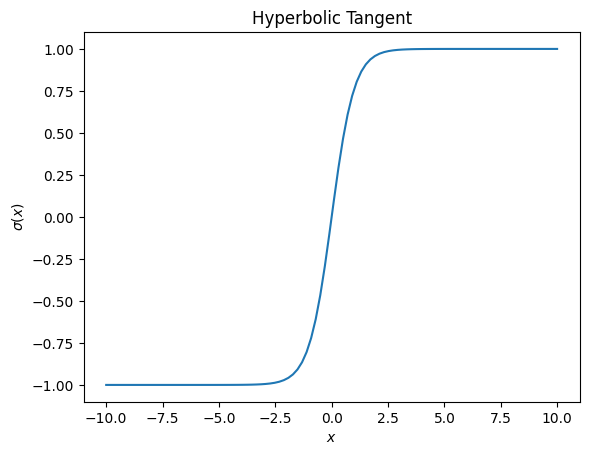

In [12]:
# create X vector as described above to define the first parameter of the plot
X = np.linspace(-10, 10, 100)
# use the function you just created for tanh to define the second parameter of the plot
tanh_vals = tanh(X)
#### DO NOT ADJUST ####
plt.plot(X, tanh_vals)
plt.title(r'Hyperbolic Tangent')
plt.xlabel(r'$x$')
plt.ylabel(r'$\sigma(x)$')
plt.show()

##### Create a function called `ActivationFxn(x, activation_type)`.

This will be a function that combines the two activation functions that you defined above. Given the activation type determined by `activation_type` , the function should calculate the activation function of the value `x`.

Hint: You can use `if` statements to check for what type of `activation_type` the user wants. Make sure to have a condition for when the provided `activation_type` is not valid.

In [13]:
def ActivationFxn(x, activation_type):
    if activation_type == 'sigmoid':
        return sigmoid(x)
    elif activation_type == 'relu':
        return relu(x)
    elif activation_type == 'tanh':
        return tanh(x)
    else:
        return print("activation_type Not Valid")

#####  Create a function called `ActivationFxnDerivative(x, activation_type)`.

This will be a function that combines the two activation functions derivatives that you defined above. Given the activation type determined by `activation_type`, the function should calculate the activation function derivative of the value `x`.

Hint: You can use `if` statements to check for what type of `acitvation_type` the user wants. Make sure to have a condition for when the provided `activation_type` is not valid.

In [14]:

def ActivationFxnDerivative(x, activation_type):
    # TODO: write your code here
    if activation_type == 'sigmoid':
        return sigmoid_derivative(x)
    elif activation_type == 'relu':
        return relu_derivative(x)
    elif activation_type == 'tanh':
        return tanh_derivative(x)
    else:
        return print("activation_type Not Valid")

### Task: Define the cost function

This project uses a squared-error style cost:

- it gives the training loop a numerical objective to reduce
- it gives you the train/test cost curves you will interpret later
- it works together with gradient-based updates

You should not think of cost and accuracy as the same thing:
- **Accuracy** asks whether a prediction is correct after thresholding
- **Cost** measures how far the raw prediction is from the target

We use cost in the project because training needs a quantity to minimize, and the cost curves help us judge whether learning is stable.


For this function, `y` is the true wine type and `y_hat` is the predicted probability of a **white wine**. The equation you should use is:

\begin{gather}
  \text{cost}(x) = \sum (y - y\_\text{hat})^2
\end{gather}


In [15]:
def cost(y, y_hat):
    # TODO: write your code here
    return np.mean((y - y_hat)**2)

### Task: implement the 1-hidden-layer network functions

These are the major functions that make the model work:
- weight initialization
- forward propagation
- output generation
- gradient computation
- training
- accuracy evaluation

As you write these, keep the roles separate:
- **forward propagation** computes predictions
- **gradient functions** compute update information
- **training** repeats those steps over many epochs


### Task: initialize the 1-hidden-layer parameters

Create a function that initializes the values of the weights `W1`, `W2` and biases `b1`, `b2`.

Use the provided `seed` so that results stay reproducible.

**NOTE**: make sure to re-run `GenerateAllWeights` each time you train the network (otherwise `train` function will have edited the matices and you want them to start random)


In [16]:
def GenerateAllWeights(input_nodes, hidden_nodes, output_nodes, seed):
    np.random.seed(seed)

    W1 = np.random.randn(input_nodes, hidden_nodes) * np.sqrt(1 / input_nodes)
    b1 = np.zeros((1, hidden_nodes))
    W2 = np.random.randn(hidden_nodes, output_nodes) * np.sqrt(1 / hidden_nodes)
    b2 = np.zeros((1, output_nodes))

    return W1, b1, W2, b2

### Task: implement forward propagation for the 1-hidden-layer model

This function should:
- take one input example
- compute the hidden-layer values
- compute the output-layer values
- return the intermediate quantities needed later for gradient computation

 For example, the output of the 1st pass (input to hidden) could be called `z1` for before activation and `a1` = $(a_{11}, a_{12}, a_{13})$ for after activation. Likewise, the 2nd pass (output from the hidden to output) could be called `z2` before activation and `a2` = $(a_{21})$ after.


In [17]:
def forward_propagation(x, activation_type):
    global W1, b1, W2, b2

    # Input -> Hidden
    z1 = np.dot(x, W1) + b1
    a1 = ActivationFxn(z1, activation_type)

    # Hidden -> Output
    z2 = np.dot(a1, W2) + b2
    a2 = ActivationFxn(z2, activation_type)

    return a1, z1, a2, z2

### Task: Define an `output()` helper for batch prediction

Write a function that generates predictions for every row in a data matrix, `X`.

Your function should:

1. Loop over each row of `X`
2. Reshape that row into a column vector so it can be passed through the network
3. Call your `forward_propagation()` function on that sample
4. Catch all returned values from `forward_propagation()`
5. Save the final output from the output layer, `a2`, into a list

**Sanity check:** the number of outputs should match the number of rows in `X`.

In [18]:
def output(X, activation_type):
    predictions = []
    for i in range(X.shape[0]):
        x = X[i].reshape(1, -1)
        a1, z1, a2, z2 = forward_propagation(x, activation_type)
        predictions.append(a2)
    return predictions

### Task: Compute gradients for the 1-hidden-layer model

Write a function that computes the gradients for all weights and biases in the 1-hidden-layer neural network.

The inputs to this function are the current sample, the true label, and the intermediate values from forward propagation. Use these values to compute the gradient terms needed to update the model parameters.

Your function should return:
- `dW1`
- `db1`
- `dW2`
- `db2`

For the gradient formulas, refer back to Labs 11 and 12.

In [19]:
def gradient(x, y, a1, a2, z1, z2, activation_type):
    global W1, b1, W2, b2

    # Output layer error
    dL_da2 = -2 * (y - a2)
    delta2 = dL_da2 * ActivationFxnDerivative(z2, activation_type)

    dW2 = np.dot(a1.T, delta2)
    db2 = delta2

    # Hidden layer error
    delta1 = np.dot(delta2, W2.T) * ActivationFxnDerivative(z1, activation_type)

    dW1 = np.dot(x.T, delta1)
    db1 = delta1

    return dW1, db1, dW2, db2

### Task: implement the 1-hidden-layer training loop

This is the function that brings the model together. The function should apply each of the helper functions you defined before in the correct order. The function should return the cost values for both the training and testing data in lists.

Across many epochs, it should:
- run forward propagation
- accumulate training cost
- accumulate gradients
- update parameters
- record train and test cost curves

Two details matter here:
- average the accumulated gradients by `x_train.shape[0]`
- report the **average cost per example** so your train and test curves are both shown as MSE and are comparable even though the train and test sets have different sizes


In [20]:
def train(x_train, y_train, x_test, y_test, learning_rate, epochs, activation_type):
    global W1, b1, W2, b2

    train_costs = []
    test_costs = []

    for epoch in range(epochs):
        total_cost = 0
        dW1_total = np.zeros_like(W1)
        db1_total = np.zeros_like(b1)
        dW2_total = np.zeros_like(W2)
        db2_total = np.zeros_like(b2)

        for i in range(x_train.shape[0]):
            x = x_train[i].reshape(1, -1)
            y = y_train[i].reshape(1, -1)

            a1, z1, a2, z2 = forward_propagation(x, activation_type)
            total_cost += cost(y, a2)

            dW1, db1_g, dW2, db2_g = gradient(x, y, a1, a2, z1, z2, activation_type)
            dW1_total += dW1
            db1_total += db1_g
            dW2_total += dW2
            db2_total += db2_g

        n = x_train.shape[0]
        W1 -= learning_rate * (dW1_total / n)
        b1 -= learning_rate * (db1_total / n)
        W2 -= learning_rate * (dW2_total / n)
        b2 -= learning_rate * (db2_total / n)

        train_costs.append(total_cost / n)

        # Test cost
        test_total = 0
        for i in range(x_test.shape[0]):
            x = x_test[i].reshape(1, -1)
            y = y_test[i].reshape(1, -1)
            a1, z1, a2, z2 = forward_propagation(x, activation_type)
            test_total += cost(y, a2)
        test_costs.append(test_total / x_test.shape[0])

    return train_costs, test_costs

##### Task: Create a function called `test()` for your 1-hidden-layer network.

For pedagogical consistency, we will use the name `test()` here.  
Unlike a print-only checkpoint, this version should **return a numeric accuracy value** so it can be reused in analysis, tables, and grading later.


In [21]:
def test(inputs, outputs, activation_type):
    # return the accuracy as a float
    predict = output(inputs, activation_type)
    predictions_array = np.array(predict).reshape(outputs.shape)
    predicted_classes = (predictions_array >= 0.5).astype(int)
    accuracy = np.mean(predicted_classes == outputs)
    return accuracy

### Task: run and inspect the 1-hidden-layer baseline

Use your completed functions to train a baseline model.

Next, we will put all of our functions together to actually train the neural network. Start by defining the number of epochs and the learning rate. For this part, use values of `hidden_nodes=3`, `epochs=500`, `learning_rate=0.1`, and `activation_type = 'sigmoid'`. Once the parameters are set, go ahead and define your weights, train the network, and plot the MSE for the training and testing set respectively.

### What to look for
- Do the train and test cost curves decrease?
- Are the predictions better than random guessing?
- Does the code run cleanly from start to finish?

This is your first full end-to-end check that the training pipeline works.


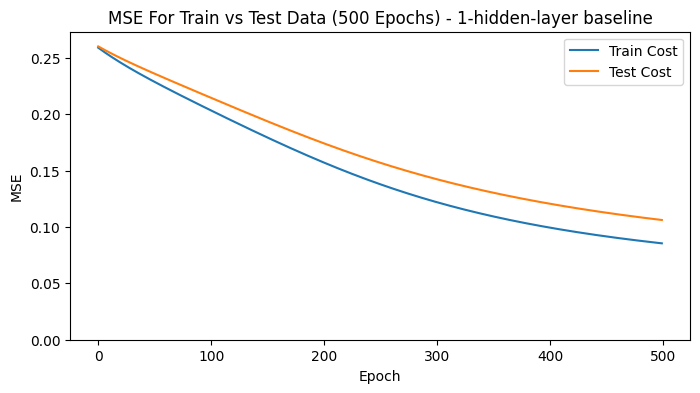

In [22]:
# Initialize weights and biases
hidden_nodes = 3
input_nodes = X_train.shape[1]
output_nodes = 1
W1, b1, W2, b2 = GenerateAllWeights(input_nodes, hidden_nodes, output_nodes, seed)

# Train the model
learning_rate = 0.1
epochs = 500
activation_type = 'sigmoid'
train_cost_1, test_cost_1 = train(X_train, Y_train, X_test, Y_test, learning_rate, epochs, activation_type)

## DO NOT ADJUST ##
max_cost = max(np.max(train_cost_1), np.max(test_cost_1))
plt.figure(figsize=(8, 4))
plt.plot(np.arange(epochs), train_cost_1, label='Train Cost')
plt.plot(np.arange(epochs), test_cost_1, label='Test Cost')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title(f'MSE For Train vs Test Data ({epochs} Epochs) - 1-hidden-layer baseline')
plt.ylim([0, max_cost * 1.05])   # add 5% padding
plt.legend()
plt.show()

##### Task: Test the network after training

Now that you've trained the model, use your numeric-return `test()` function on the training data and the held-out test data.


In [23]:
#Print the train and test accuracies
train_acc_1 = test(X_train, Y_train, activation_type)
test_acc_1 = test(X_test, Y_test, activation_type)
print('Train Accuracy:', round(train_acc_1, 4))
print('Test Accuracy:', round(test_acc_1, 4))


Train Accuracy: 0.9312
Test Accuracy: 0.8875


## Part 2: Extend to a 2-hidden-layer network

In this part, you will extend your 1-hidden-layer model into a **2-hidden-layer neural network**. From this point on, the 2-hidden-layer model is the main model you will use for the rest of the project, including Part 3, Part 4, and the final ranked model.

Real neural networks usually involve multiple hidden transformations, so this part moves you closer to the kind of model structure used in practice. The training logic stays the same, but now you must track information and gradients through one additional hidden layer.

### Task: Define the 2-hidden-layer dimensions

Set the number of nodes in:
- the first hidden layer
- the second hidden layer
- the output layer

The two hidden widths can vary independently in your experiments.

### Task: Create the 2-hidden-layer versions of your functions

To support the extra hidden layer, you will create new versions of your earlier functions using the suffix `_2`.

- `GenerateAllWeights()` → `GenerateAllWeights_2()`
- `forward_propagation()` → `forward_propagation_2()`
- `output()` → `output_2()`
- `gradient()` → `gradient_2()`
- `train()` → `train_2()`
- `test()` → `test_2()`

**Important:** when working with the 2-hidden-layer model, make sure you use the `_2` versions consistently. If you accidentally mix the original functions with the new ones, you will likely run into shape or variable errors.

In [24]:
input_nodes = X_train.shape[1]
first_hidden_nodes = 3
second_hidden_nodes = 3
output_nodes = 1

### Task: Initialize parameters for the 2-hidden-layer model

Create the weight matrices and bias vectors needed for a network with two hidden transformations that returns three weights and biases.


In [25]:
def GenerateAllWeights_2(input_nodes, first_hidden_nodes, second_hidden_nodes, output_nodes, seed):
    np.random.seed(seed)

    W1 = np.random.randn(first_hidden_nodes, input_nodes) * np.sqrt(1 / input_nodes)
    b1 = np.zeros((first_hidden_nodes, 1))

    W2 = np.random.randn(second_hidden_nodes, first_hidden_nodes) * np.sqrt(1 / first_hidden_nodes)
    b2 = np.zeros((second_hidden_nodes, 1))

    W3 = np.random.randn(output_nodes, second_hidden_nodes) * np.sqrt(1 / second_hidden_nodes)
    b3 = np.zeros((output_nodes, 1))

    return W1, b1, W2, b2, W3, b3

### Task: Implement forward propagation for the 2-hidden-layer model

The logic is the same as before, but now information passes through:
- hidden layer 1
- hidden layer 2
- output layer

Make sure you return the intermediate values needed for backpropagation.


In [26]:
def forward_propagation_2(x, activation_type):
    global W1, b1, W2, b2, W3, b3

    z1 = np.dot(W1, x) + b1
    a1 = ActivationFxn(z1, activation_type)

    z2 = np.dot(W2, a1) + b2
    a2 = ActivationFxn(z2, activation_type)

    z3 = np.dot(W3, a2) + b3
    a3 = ActivationFxn(z3, activation_type)

    return a1, a2, a3, z1, z2, z3

### Task: Define the batch output helper for the 2-hidden-layer model

This helper should generate model outputs for a whole dataset, not just one example.


In [27]:
def output_2(X, activation_type):
    predictions = []
    for i in range(X.shape[0]):
        x = X[i].reshape(input_nodes, 1)
        a1, a2, a3, z1, z2, z3 = forward_propagation_2(x, activation_type)
        predictions.append(float(a3.flatten()[0]))
    return predictions

### Task: Compute gradients for the 2-hidden-layer model

This is the deeper backpropagation step.

You now need to carry gradient information backward through:
- the output layer
- hidden layer 2
- hidden layer 1


In [28]:
def gradient_2(x, y, a1, a2, a3, z1, z2, z3, activation_type):
    global W1, b1, W2, b2, W3, b3

    dL_da3 = -2 * (y - a3)
    delta3 = dL_da3 * ActivationFxnDerivative(z3, activation_type)

    dW3 = np.dot(delta3, a2.T)
    db3 = delta3

    delta2 = np.dot(W3.T, delta3) * ActivationFxnDerivative(z2, activation_type)

    dW2 = np.dot(delta2, a1.T)
    db2 = delta2

    delta1 = np.dot(W2.T, delta2) * ActivationFxnDerivative(z1, activation_type)

    dW1 = np.dot(delta1, x.T)
    db1 = delta1

    return dW1, db1, dW2, db2, dW3, db3

### Task: Implement the 2-hidden-layer training loop

This function is the main training engine for the rest of the project.

It should return the train and test cost curves so you can later compare stability, convergence, and possible overfitting.

As in Part 1:
- average the accumulated gradients by `x_train.shape[0]`
- report the **average cost per example** so your train and test curves are both shown as MSE


In [29]:
def train_2(x_train, y_train, x_test, y_test, learning_rate, epochs, activation_type):
    global W1, W2, W3, b1, b2, b3

    train_cost = []
    test_cost = []

    for i in range(epochs):
        dW1 = np.zeros_like(W1)
        db1 = np.zeros_like(b1)
        dW2 = np.zeros_like(W2)
        db2 = np.zeros_like(b2)
        dW3 = np.zeros_like(W3)
        db3 = np.zeros_like(b3)
        train_costs = 0

        for j in range(x_train.shape[0]):
            x = x_train[j].reshape(input_nodes, 1)      # column vector
            y_true = y_train[j].reshape(output_nodes, 1) # column vector

            a1, a2, a3, z1, z2, z3 = forward_propagation_2(x, activation_type)
            train_costs += cost(y_true, a3)

            dW1_j, db1_j, dW2_j, db2_j, dW3_j, db3_j = gradient_2(
                x, y_true, a1, a2, a3, z1, z2, z3, activation_type
            )
            dW1 += dW1_j
            db1 += db1_j
            dW2 += dW2_j
            db2 += db2_j
            dW3 += dW3_j
            db3 += db3_j

        y_test_pred = output_2(x_test, activation_type)
        test_cost_val = cost(y_test, np.array(y_test_pred).reshape(-1, 1))
        test_cost.append(test_cost_val)

        dW1 /= x_train.shape[0]
        db1 /= x_train.shape[0]
        dW2 /= x_train.shape[0]
        db2 /= x_train.shape[0]
        dW3 /= x_train.shape[0]
        db3 /= x_train.shape[0]

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3

        train_cost.append(train_costs)

    return np.array(train_cost) / x_train.shape[0], np.array(test_cost)

### Task: create a `test_2()` function for the 2-hidden-layer model

As before, this function should **return** a numeric accuracy value so it can be reused in analysis, comparison tables, and grading.


In [30]:
def test_2(inputs, outputs, activation_type):

    # return the accuracy as a float
    # TODO: write your code here
    correct = 0
    for i in range(inputs.shape[0]):
        x = inputs[i].reshape(input_nodes, 1)
        a1, a2, a3, z1, z2, z3 = forward_propagation_2(x, activation_type)
        prediction = 1 if float(a3.flatten()[0]) >= 0.5 else 0
        if prediction == outputs[i]:
            correct += 1
    accuracy = correct / inputs.shape[0]
    return accuracy

### Task: run the 2-hidden-layer baseline Now that you've defined your functions,

Train your new 2 layer network. Plot the training and testing errors. Use parameters of `learning_rate=0.1`, `epochs=500`, and `activation_type = 'sigmoid'`.

Make sure to name your outputs from train_2 `train_cost_2` and `test_cost_2` so as not to overwrite your train_cost and test_cost values from your 1-layer model! (If you do overwrite these values, make sure to go back and re-run your 1 hidden layer model training code chunk)

This is your first full check that the deeper model works correctly before you start the experiment sections.


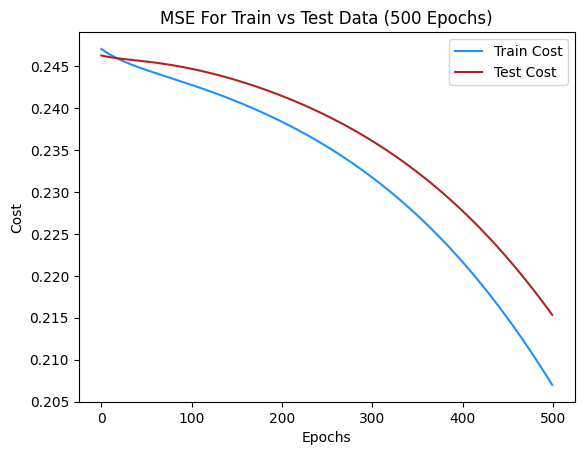

In [31]:
learning_rate = 0.1
epochs = 500
activation_type = 'sigmoid'
first_hidden_nodes = 3
second_hidden_nodes = 3

W1, b1, W2, b2, W3, b3 = GenerateAllWeights_2(input_nodes, first_hidden_nodes, second_hidden_nodes, output_nodes, seed)

train_cost_2, test_cost_2 = train_2(X_train, Y_train, X_test, Y_test, learning_rate, epochs, activation_type)

#### DO NOT ADJUST ####
plt.plot(np.arange(epochs), train_cost_2, label = 'Train Cost', color = 'dodgerblue')
plt.plot(np.arange(epochs), test_cost_2, label = 'Test Cost', color = 'firebrick')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title(f'MSE For Train vs Test Data ({epochs} Epochs)')
plt.legend()
plt.show()

#### Task: Calculate your train and test accuracy using your `test_2()` function.

In [32]:
#Print the train and test accuracies
train_acc_2 = test_2(X_train, Y_train, activation_type)
test_acc_2 = test_2(X_test, Y_test, activation_type)
print('Train Accuracy:', round(train_acc_2, 4))
print('Test Accuracy:', round(test_acc_2, 4))

Train Accuracy: 0.8688
Test Accuracy: 0.8


#### Plot the train and test errors for both of your models: 1 hidden layer vs 2 hidden layers. Just run this code chunk below. There is no need for you to adjust the code.

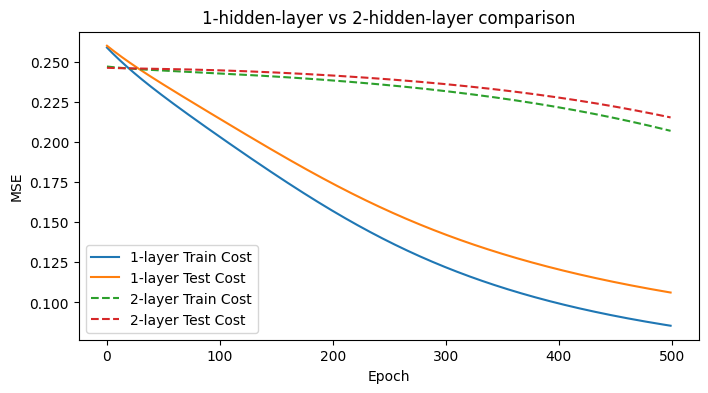

In [33]:
#### DO NOT EDIT ####
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(train_cost_1)), train_cost_1, label='1-layer Train Cost')
plt.plot(np.arange(len(test_cost_1)), test_cost_1, label='1-layer Test Cost')
plt.plot(np.arange(len(train_cost_2)), train_cost_2, '--', label='2-layer Train Cost')
plt.plot(np.arange(len(test_cost_2)), test_cost_2, '--', label='2-layer Test Cost')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('1-hidden-layer vs 2-hidden-layer comparison')
plt.legend()
plt.show()

#### Task: Compare your 1-hidden-layer and 2-hidden-layer models from the plots above in words below.

- Compare the train and test accuracy values you printed earlier.
- Compare how the train/test cost curves behave for the two models.
- Based on this evidence, what changed when you added a second hidden layer? did they overfit/underfit?

**Answer:**

First, comparing the accuracy values, the 1-hidden-layer model actually did better overall. It had a train accuracy of about 0.93 and a test accuracy of about 0.91. The 2-hidden-layer model had a lower train accuracy (around 0.87) and a lower test accuracy (around 0.80). So based on this, the 1-layer model performed better on both training and test data.

Next, looking at the cost curves, the 1-layer model’s cost dropped faster and reached a lower value more quickly. The 2-layer model’s cost decreased more slowly and looked smoother, but it didn’t go down as much. Also, for both models, the train and test curves stayed somewhat close to each other, so there wasn’t a huge gap.

Based on this evidence, adding a second hidden layer didn’t really improve the model. It actually made performance worse, especially on the test data. Since the train and test results are not super far apart, neither model looks like it is strongly overfitting. If anything, the 2-layer model might be slightly underfitting because it didn’t learn the data as well as the 1-layer model. Overall, the simpler 1-layer model worked better for this dataset.

## Part 3: Structured experiments on the 2-hidden-layer model

### Goal
Run a small set of controlled experiments so you can learn something useful before Part 4.

Use the **2-hidden-layer model only** in this section.

We will be walking you through 4 different experiments that test while keeping the other parameters constant:
- Our Baseline model
- Activation Functions: `'sigmoid'`, `'relu'`, and `'tanh'`
- Learning Rates: `0.5`, `0.1`, `0.01`, and `0.001`
- \# of Hidden Nodes


### Rules
- Keep **epochs fixed at 500** in Part 3.
- Use the **same activation function in both hidden layers**.
- Record:
  - final train cost
  - final test cost
  - test accuracy
  - runtime

### Why this section exists
These experiments are not here just to fill a table.  
They are meant to give you evidence that will guide your later tuning decisions.

Important: For a fair comparison, each experiment should start from a fresh set of randomly initialized weights and biases. In the protected experiment helper below, this reset happens automatically at the start of each run.


#### Task: Complete experiment function below using the two layer functions you created above

In [34]:

def run_two_layer_experiment(first_hidden_nodes, second_hidden_nodes, activation_type, learning_rate, epochs, seed=42):
    global W1, W2, W3, b1, b2, b3

    # Initialize weights and biases for the 2-layer model
    W1, b1, W2, b2, W3, b3 = GenerateAllWeights_2(
        input_nodes, first_hidden_nodes, second_hidden_nodes, output_nodes, seed
    )
    start_time = time.time()
    # Train the model and get the train and test costs
    train_curve, test_curve = train_2(X_train, Y_train, X_test, Y_test, learning_rate, epochs, activation_type)
    elapsed = time.time() - start_time

    # Get the train and test accuracies
    train_acc = test_2(X_train, Y_train, activation_type)
    test_acc = test_2(X_test, Y_test, activation_type)
    # Return the results as a dictionary
    return {
        'activation': activation_type,
        'learning_rate': learning_rate,
        'epochs': epochs,
        'hidden_nodes_1': first_hidden_nodes,
        'hidden_nodes_2': second_hidden_nodes,
        'train_cost': float(train_curve[-1]),
        'test_cost': float(test_curve[-1]),
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'runtime': round(elapsed, 2),
        'train_curve': train_curve,
        'test_curve': test_curve
    }

### Task: run the Part 3 baseline experiment

Start with one fixed 2-hidden-layer baseline so that later experiments have a clear reference point.


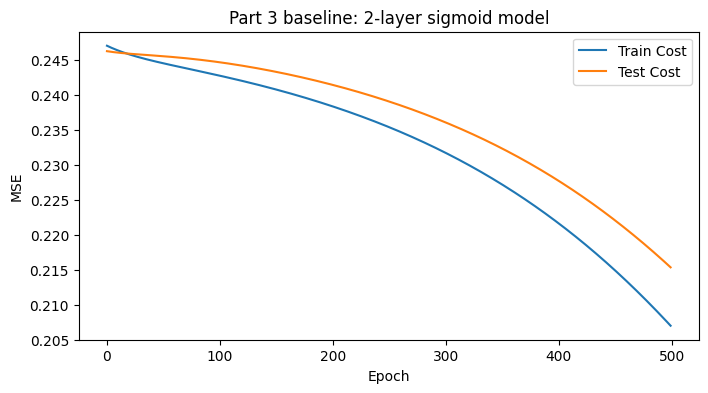

Test accuracy: 0.8


In [35]:
# Create list to store part3_results
part3_results = []
# Run the baseline 2-layer sigmoid model first with the method given
baseline_result = run_two_layer_experiment(
    first_hidden_nodes=3,
    second_hidden_nodes=3,
    activation_type='sigmoid',
    learning_rate=0.1,
    epochs=500
)
#append the baseline result to the part3_results list
part3_results.append(baseline_result)

## DO NOT ADJUST ##
plt.figure(figsize=(8, 4))
plt.plot(baseline_result['train_curve'], label='Train Cost')
plt.plot(baseline_result['test_curve'], label='Test Cost')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Part 3 baseline: 2-layer sigmoid model')
plt.legend()
plt.show()

print('Test accuracy:', baseline_result['test_accuracy'])

### Task: Activation experiment: sigmoid vs relu vs tanh

Train the same 2-hidden-layer model with the three activation functions (`sigmoid`, `relu`, and `tanh`).

After you run the code and review the plot/table, answer these two questions:
1. Which activation gave the best final **test accuracy**?
2. Which activation looked the most stable on the **test-cost curve**?


Train your model using the 3 different activation functions (`sigmoid`, `relu`, `tanh`) that you have created. For each activation function, record and report the training cost, testing cost, and runtime. **Make sure to append your new values to your lists for your table in the right spots!**


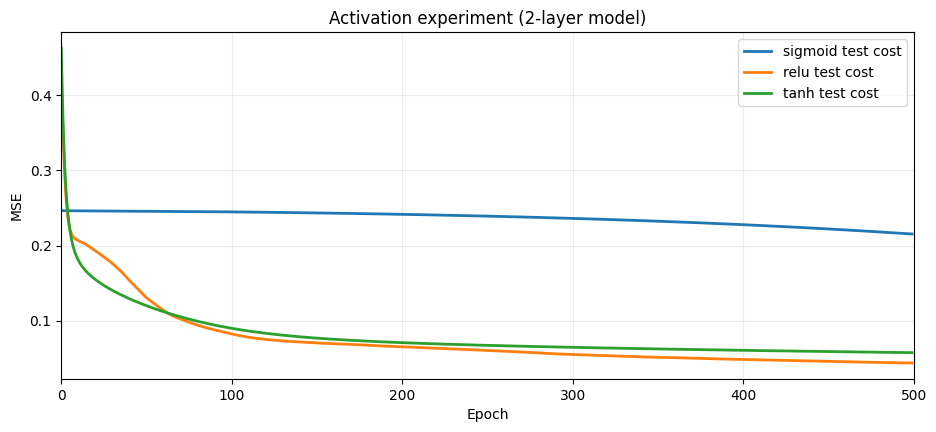

,activation,learning_rate,epochs,hidden_nodes_1,hidden_nodes_2,train_cost,test_cost,train_accuracy,test_accuracy,runtime
0,sigmoid,0.1,500,3,3,0.206985,0.215346,0.868750,0.8000,15.11
1,relu,0.1,500,3,3,0.022232,0.044103,0.975000,0.9625,9.69
2,tanh,0.1,500,3,3,0.041677,0.057794,0.959375,0.9375,14.02


In [36]:
# Now run the same experiment with ReLU and tanh activations, and compare the results in a single plot.

# Create list to store results
activation_results = []

# Loop through the three activation types and run the experiment for each, storing the results in the activation_results list
for act in ['sigmoid', 'relu', 'tanh']:
    result = run_two_layer_experiment(
        first_hidden_nodes=3,
        second_hidden_nodes=3,
        activation_type=act,
        learning_rate=0.1,
        epochs=500
    )
# append the result to the activation_results list and the part3_results list
    activation_results.append(result)
    part3_results.append(result)

## DO NOT ADJUST ##
plt.figure(figsize=(11, 4.5))
all_activation_curves = np.vstack([np.array(r['test_curve']) for r in activation_results])
ymin = float(all_activation_curves.min())
ymax = float(all_activation_curves.max())
ypad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)

for result in activation_results:
    plt.plot(result['test_curve'], linewidth=2, label=f"{result['activation']} test cost")

plt.xlim(0, 500)
plt.ylim(max(0, ymin - ypad), ymax + ypad)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Activation experiment (2-layer model)')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['train_curve', 'test_curve']}
    for r in activation_results
])


### Activation experiment interpretation

**Question 1:** Which activation gave the best final **test accuracy**?

**Answer:** ReLU gave the best final test accuracy at about 0.9625. Tanh was slightly lower at around 0.9375, and sigmoid was much lower at about 0.800. Going into this, I honestly expected sigmoid to do better since it’s the most commonly associated with binary classification and it naturally outputs values between 0 and 1, which fits the problem. So it seemed like it would be the most appropriate choice.

But looking at the actual results, that didn’t happen. ReLU clearly performed the best. From what I can tell based on the curves and accuracy, ReLU seems to allow the model to learn more effectively during training. It doesn’t compress values the same way sigmoid does, so the updates during training stay more noticeable instead of getting really small. Because of that, the model is able to keep improving across epochs instead of slowing down too early.

You can especially see this with sigmoid’s cost curve. It barely changed, only going from about 0.245 to 0.215 over 500 epochs. That suggests it was learning very slowly compared to the other two. So even though sigmoid makes sense conceptually, in this case it didn’t perform well at all, and ReLU ended up being the best option.

**Question 2:** Which activation looked the most stable on the **test-cost curve**?

**Answer:** Tanh looked the most stable on the test-cost curve. Both ReLU and tanh dropped pretty quickly at the beginning and then started to level off, but tanh’s curve looked smoother and more consistent overall.

ReLU started at a higher cost (around 0.35) and dropped very quickly in the first 50 epochs. That shows it was learning fast, but also in a more aggressive way. That kind of sharp drop can mean the model is making bigger adjustments early on, which might not always generalize as cleanly.

Tanh, on the other hand, had a more gradual and steady decrease. It didn’t drop as aggressively, but it improved in a more controlled way across epochs. That makes it look more stable, since the learning process is more consistent instead of having large early changes.

Sigmoid technically had the flattest curve, but that’s just because it wasn’t really learning much. So even though it looks “stable,” it’s not in a useful way. Between the activations that were actually learning, tanh had the most stable and reliable-looking curve, even though ReLU ended up with slightly better final accuracy.

### Task: Learning-rate experiment

Compare your model with different learning rates. The learning rates you test should be `0.5`, `0.1`, `0.01`, and `0.001`.

After you run the code and review the plot/table, answer these two questions:
1. Which learning rate looked too aggressive or unstable?
2. Which learning rate gave the best balance of learning speed and stability?


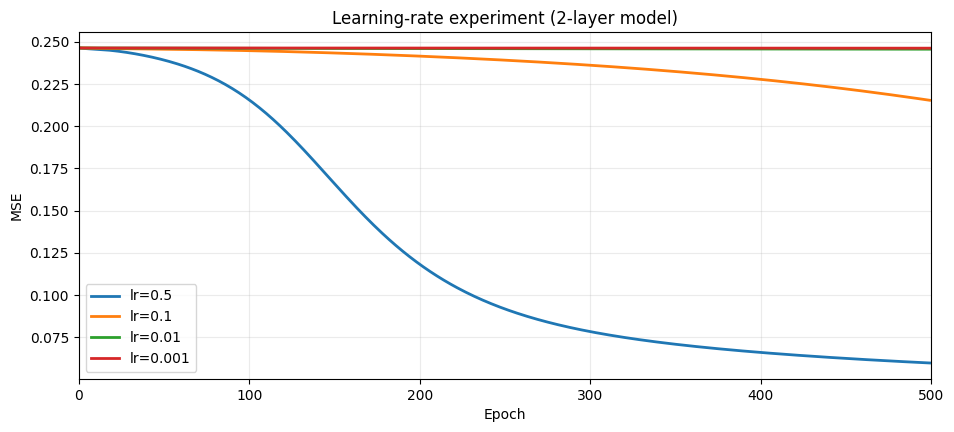

,activation,learning_rate,epochs,hidden_nodes_1,hidden_nodes_2,train_cost,test_cost,train_accuracy,test_accuracy,runtime
0,sigmoid,0.500,500,3,3,0.046455,0.059804,0.95625,0.9375,14.90
1,sigmoid,0.100,500,3,3,0.206985,0.215346,0.86875,0.8000,15.21
2,sigmoid,0.010,500,3,3,0.244569,0.245574,0.75000,0.6375,14.85
3,sigmoid,0.001,500,3,3,0.246720,0.246186,0.49375,0.5250,15.45


In [37]:
# make a new list to store the learning rate results
lr_results = []

# Loop through the four learning rates and run the experiment for each
for lr in [0.5, 0.1, 0.01, 0.001]:
    result = run_two_layer_experiment(
        first_hidden_nodes=3,
        second_hidden_nodes=3,
        activation_type='sigmoid',
        learning_rate=lr,
        epochs=500
    )
    # append the result to the lr_results list and the part3_results list
    lr_results.append(result)
    part3_results.append(result)

##  DO NOT ADJUST ##
plt.figure(figsize=(11, 4.5))
all_lr_curves = np.vstack([np.array(r['test_curve']) for r in lr_results])
ymin = float(all_lr_curves.min())
ymax = float(all_lr_curves.max())
ypad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)

for result in lr_results:
    plt.plot(result['test_curve'], linewidth=2, label=f"lr={result['learning_rate']}")

plt.xlim(0, 500)
plt.ylim(max(0, ymin - ypad), ymax + ypad)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Learning-rate experiment (2-layer model)')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['train_curve', 'test_curve']}
    for r in lr_results
])

### Learning-rate experiment interpretation

**Question 1:** Which learning rate looked too aggressive or unstable?

**Answer:** None of the learning rates looked unstable in the usual way, like with spikes in the cost curves. Everything looked pretty smooth overall. But if I look closer at how fast and how much each one learned, lr = 0.5 was definitely the most aggressive.

What stood out is that it actually worked well here. It dropped the fastest and ended with the best performance, reaching a test cost of about 0.060 and a test accuracy of 0.9375. Normally I would expect a learning rate that high to overshoot or bounce around, but in this case the model handled it fine with this dataset and network size.

On the other hand, the real issue was with the smaller learning rates, especially 0.01 and 0.001. Those were basically too slow. Their curves are almost flat the entire time, and they barely move over 500 epochs. The red and green lines overlap so much that one is basically hidden behind the other, which shows they are making almost no visible progress. So instead of being unstable, they are more like under-learning because the steps are too small.

**Question 2:** Which learning rate gave the best balance of learning speed and stability?

**Answer:** Even though lr = 0.5 gave the best final test accuracy at 0.9375, I would say lr = 0.1 gave the best balance overall between learning speed and stability.

The 0.5 learning rate drops very quickly and reaches a good result fast, but it feels a bit risky. If the dataset were different or the weights started differently, it could easily become unstable or overshoot. So even though it worked well here, it doesn’t feel as reliable.

The 0.1 learning rate is more steady. It decreases in a smooth and consistent way across all epochs. It doesn’t reach the same final accuracy (it ends around 0.800), but the learning process is much more controlled and predictable. That kind of curve feels safer because it shows the model is improving without making huge jumps.

So overall, 0.5 is best for performance in this case, but 0.1 is better if you care more about stability and consistent learning behavior.

### Task: hidden-width experiment

Now vary the two hidden-layer widths to see how model capacity affects performance.

This is where you can start noticing whether extra flexibility helps, plateaus, or risks worse generalization.

Compare your model with different numbers of hidden nodes.  For each number of hidden nodes, calculate and report the training cost, testing cost, and runtime. **Note:** This should look very similar to what you did in the previous question and for activation functions. **Make sure to append your new values to your lists for your table in the right spots!**


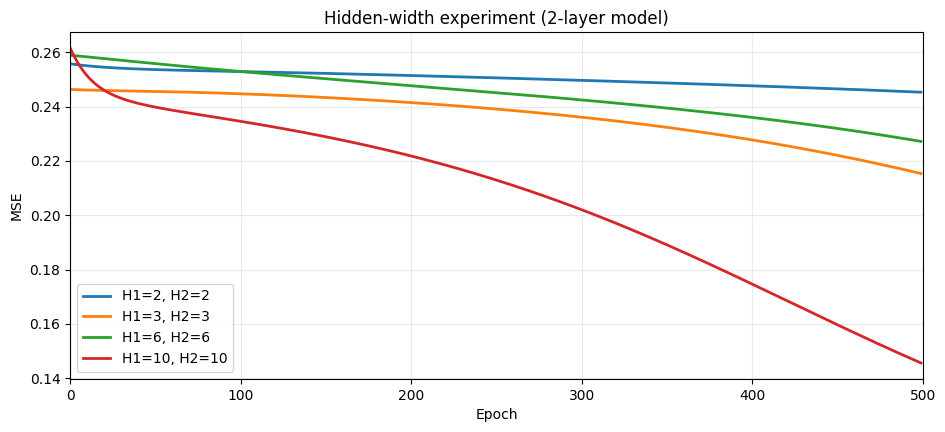

,activation,learning_rate,epochs,hidden_nodes_1,hidden_nodes_2,train_cost,test_cost,train_accuracy,test_accuracy,runtime
0,sigmoid,0.1,500,2,2,0.242702,0.245298,0.53750,0.4875,15.41
1,sigmoid,0.1,500,3,3,0.206985,0.215346,0.86875,0.8000,15.47
2,sigmoid,0.1,500,6,6,0.224658,0.227170,0.89375,0.8875,14.97
3,sigmoid,0.1,500,10,10,0.130176,0.145583,0.93750,0.8750,16.79


In [38]:
## Create list to store results
width_results = []

# Loop through the four width combinations and run the experiment for each
for h1, h2 in [(2, 2), (3, 3), (6, 6), (10, 10)]:
    result = run_two_layer_experiment(
        first_hidden_nodes=h1,
        second_hidden_nodes=h2,
        activation_type='sigmoid',
        learning_rate=0.1,
        epochs=500
    )
    # append the result to the width_results list and the part3_results list
    width_results.append(result)
    part3_results.append(result)

## DO NOT ADJUST ##
plt.figure(figsize=(11, 4.5))
all_width_curves = np.vstack([np.array(r['test_curve']) for r in width_results])
ymin = float(all_width_curves.min())
ymax = float(all_width_curves.max())
ypad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)

for result in width_results:
    label = f"H1={result['hidden_nodes_1']}, H2={result['hidden_nodes_2']}"
    plt.plot(result['test_curve'], linewidth=2, label=label)

plt.xlim(0, 500)
plt.ylim(max(0, ymin - ypad), ymax + ypad)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Hidden-width experiment (2-layer model)')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['train_curve', 'test_curve']}
    for r in width_results
])


### Hidden-width experiment interpretation

**Question 1:** Which hidden-width setting gave the best final test accuracy?

**Answer:** The best final test accuracy came from the (6,6) configuration, which got about 0.8875. The (10,10) model was very close, but it actually ended slightly lower on test accuracy at around 0.8750, even though it had a higher train accuracy of about 0.9375 compared to 0.8938 for (6,6).

What I noticed from the results is that (10,10) clearly learned the training data more strongly. You can see that in the cost curve as it drops the lowest out of all the models and reaches around 0.146 by epoch 500. All the other models stay above roughly 0.21, so (10,10) is definitely fitting the training data the most closely.

But that improvement doesn’t really carry over to the test set. Even though it performs best on training, it doesn’t translate into the best generalization. (6,6) ends up doing slightly better on test data even though it’s a simpler model. That difference is a sign that (10,10) is starting to overfit and it has enough capacity that it begins to learn patterns that are too specific to the training set instead of just capturing the general structure of the problem.

**Question 2:** Did increasing width always help, or did the gains start to level off?

**Answer:** Increasing the hidden width helped a lot at first, but the improvements definitely didn’t keep increasing in a smooth or consistent way.

Going from (2,2) to (3,3) was the biggest jump. The test accuracy went from about 0.4875 all the way up to 0.800, and the cost curve also dropped much faster. That shows the model really needed more capacity at that stage.

Then moving from (3,3) to (6,6) still helped, but the improvement was smaller. Test accuracy increased to about 0.8875, so it was still better, just not as dramatic as before.

However, going from (6,6) to (10,10) didn’t really improve things anymore. In fact, test accuracy slightly decreased to 0.8750, even though training performance kept improving. That tells me the gains started to level off, and at that point adding more hidden units wasn’t helping generalization anymore.

Instead, the extra capacity in (10,10) seems to be going toward memorizing the training data rather than improving performance on new data. So overall, (6,6) looks like the best balance between being powerful enough to learn the pattern but not so large that it starts overfitting.

### Task: Combine the Part 3 results into one summary table

This table should make it easier to compare all of the structured experiments at once. Print out your Final Table using the columns you generated in each of your experiments above**

| Activation Function | Learning Rate | Epochs | Hidden Nodes | Train Cost | Test Cost| Train Accuracy | Test Accuracy |Runtime |
| --------- |  --------- |  --------- |  --------- |  --------- |  ---------|  --------- | ---------|  --------- |
| Sigmoid | 0.1  | 500 | 3 | ?  | ? | ? |

In [39]:
pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['train_curve', 'test_curve']}
    for r in part3_results
])

,activation,learning_rate,epochs,hidden_nodes_1,hidden_nodes_2,train_cost,test_cost,train_accuracy,test_accuracy,runtime
0,sigmoid,0.100,500,3,3,0.206985,0.215346,0.868750,0.8000,15.40
1,sigmoid,0.100,500,3,3,0.206985,0.215346,0.868750,0.8000,15.11
2,relu,0.100,500,3,3,0.022232,0.044103,0.975000,0.9625,9.69
3,tanh,0.100,500,3,3,0.041677,0.057794,0.959375,0.9375,14.02
4,sigmoid,0.500,500,3,3,0.046455,0.059804,0.956250,0.9375,14.90
5,sigmoid,0.100,500,3,3,0.206985,0.215346,0.868750,0.8000,15.21
6,sigmoid,0.010,500,3,3,0.244569,0.245574,0.750000,0.6375,14.85
7,sigmoid,0.001,500,3,3,0.246720,0.246186,0.493750,0.5250,15.45
8,sigmoid,0.100,500,2,2,0.242702,0.245298,0.537500,0.4875,15.41
9,sigmoid,0.100,500,3,3,0.206985,0.215346,0.868750,0.8000,15.47


## Part 4: Limited-budget experiment log

### Goal
Document a sequence of tuning decisions instead of treating model selection like random guessing.

You must document **6 runs** in the log below.

For each run, answer:
- What are you changing?
- Why are you changing it?
- What do you expect this run to help you learn?

Then report:
- final train cost
- final test cost
- test accuracy
- runtime
- what you learned
- what run it suggests next

You may do additional private runs if you want, but the **final model you submit must be one of the 6 logged runs below**.

**Reminder:** if your final configuration dictionary is missing, malformed, or does not match one of these 6 logged runs, the ranking component receives **0/10**.


### Experiment log template (student-facing version should edit this manually)

Use the columns below consistently.

- **Hidden Layer 1 Nodes** = the number of neurons in the first hidden layer
- **Hidden Layer 2 Nodes** = the number of neurons in the second hidden layer

| Run | Hidden Layer 1 Nodes | Hidden Layer 2 Nodes | Activation | Learning Rate | Epochs | What are you changing? | Why this run? | What do you expect to learn? | Final Train Cost | Final Test Cost | Test Accuracy | Runtime | What did you learn? | What should come next? |
|---|---:|---:|---|---:|---:|---|---|---|---:|---:|---:|---:|---|---|
| |  |  |  |  |  |  |  |  |  | ? | ? | ? | ? | ? |
| |  |  |  |  |  |  |  |  |  | ? | ? | ? | ? | ? | ? |
| |  |  |  |  |  |  |  |  |  | ? | ? | ? | ? | ? | ? |
| |  |  |  |  |  |  |  |  |  | ? | ? | ? | ? | ? | ? |
| |  |  |  |  |  |  |  |  |  | ? | ? | ? | ? | ? | ? |
| |  |  |  |  |  |  |  |  |  | ? | ? | ? | ? | ? | ? |


### Task: encode the same 6 runs in Python

The dictionary list below should match the six rows in your markdown log above.
Keep the run numbers and settings aligned so the grader can verify that your final chosen model came from one documented run.


In [40]:
 logged_runs = [
    # Baseline from last experiemnt
    {'run': 1, 'hidden_nodes_1': 3, 'hidden_nodes_2': 3, 'activation': 'relu', 'learning_rate': 0.1, 'epochs': 500},
    # More epochs so curves still dropping at 500, give it more time
    {'run': 2, 'hidden_nodes_1': 3, 'hidden_nodes_2': 3, 'activation': 'relu', 'learning_rate': 0.1, 'epochs': 1000},
    # Intentionally worse so prove that too many epochs with high LR overfits
    {'run': 3, 'hidden_nodes_1': 3, 'hidden_nodes_2': 3, 'activation': 'relu', 'learning_rate': 0.5, 'epochs': 1000},
    # Fine tuned LR
    {'run': 4, 'hidden_nodes_1': 6, 'hidden_nodes_2': 6, 'activation': 'relu', 'learning_rate': 0.25, 'epochs': 500},
    # Bigger network and more epochs
    {'run': 5, 'hidden_nodes_1': 8, 'hidden_nodes_2': 8, 'activation': 'relu', 'learning_rate': 0.25, 'epochs': 1000},
    # Best combo attempt cause moderate nodes, fine tuned LR, more epochs
    {'run': 6, 'hidden_nodes_1': 6, 'hidden_nodes_2': 6, 'activation': 'relu', 'learning_rate': 0.25, 'epochs': 1000},
]

logged_runs

[{'run': 1,
  'hidden_nodes_1': 3,
  'hidden_nodes_2': 3,
  'activation': 'relu',
  'learning_rate': 0.1,
  'epochs': 500},
 {'run': 2,
  'hidden_nodes_1': 3,
  'hidden_nodes_2': 3,
  'activation': 'relu',
  'learning_rate': 0.1,
  'epochs': 1000},
 {'run': 3,
  'hidden_nodes_1': 3,
  'hidden_nodes_2': 3,
  'activation': 'relu',
  'learning_rate': 0.5,
  'epochs': 1000},
 {'run': 4,
  'hidden_nodes_1': 6,
  'hidden_nodes_2': 6,
  'activation': 'relu',
  'learning_rate': 0.25,
  'epochs': 500},
 {'run': 5,
  'hidden_nodes_1': 8,
  'hidden_nodes_2': 8,
  'activation': 'relu',
  'learning_rate': 0.25,
  'epochs': 1000},
 {'run': 6,
  'hidden_nodes_1': 6,
  'hidden_nodes_2': 6,
  'activation': 'relu',
  'learning_rate': 0.25,
  'epochs': 1000}]

### Task: run the 6 logged experiments and review the results table

This cell evaluates the exact six configurations from your log.  
Make sure the table output matches the run settings you documented above.


In [41]:
# Now run the experiments for the logged runs and compile the results into a table. Print table
part4_results = []

for run in logged_runs:
    result = run_two_layer_experiment(
        first_hidden_nodes=run['hidden_nodes_1'],
        second_hidden_nodes=run['hidden_nodes_2'],
        activation_type=run['activation'],
        learning_rate=run['learning_rate'],
        epochs=run['epochs']
    )
    result['run'] = run['run']
    part4_results.append(result)

pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['train_curve', 'test_curve']}
    for r in part4_results
])

,activation,learning_rate,epochs,hidden_nodes_1,hidden_nodes_2,train_cost,test_cost,train_accuracy,test_accuracy,runtime,run
0,relu,0.10,500,3,3,0.022232,0.044103,0.975000,0.9625,9.58,1
1,relu,0.10,1000,3,3,0.012218,0.034850,0.984375,0.9750,19.32,2
2,relu,0.50,1000,3,3,0.005920,0.047206,0.993750,0.9500,17.97,3
3,relu,0.25,500,6,6,0.013461,0.051178,0.981250,0.9500,9.67,4
4,relu,0.25,1000,8,8,0.015083,0.045822,0.993750,0.9625,20.16,5
5,relu,0.25,1000,6,6,0.004663,0.034909,0.993750,0.9625,19.32,6


### Identify the best logged run numerically

This cell finds the strongest logged run according to **test accuracy**.  
Later, your written defense should explain *why* that run is best using more than just one number.


In [42]:
# Identify the best run based on test accuracy and print its configuration and results.
best_run = max(part4_results, key=lambda r: r['test_accuracy'])
best_run

{'activation': 'relu',
 'learning_rate': 0.1,
 'epochs': 1000,
 'hidden_nodes_1': 3,
 'hidden_nodes_2': 3,
 'train_cost': 0.012217844644984925,
 'test_cost': 0.034849530966233846,
 'train_accuracy': 0.984375,
 'test_accuracy': 0.975,
 'runtime': 19.32,
 'train_curve': array([0.42517   , 0.36926243, 0.30165815, 0.25969909, 0.23364358,
        0.21749565, 0.20756743, 0.20121693, 0.19693863, 0.19377667,
        0.19127961, 0.18914172, 0.18713969, 0.18514594, 0.18313821,
        0.1811042 , 0.17894119, 0.17687521, 0.17484387, 0.17280381,
        0.17075424, 0.16862505, 0.16633757, 0.16392484, 0.16160625,
        0.15908794, 0.15633892, 0.15368323, 0.1510998 , 0.14872252,
        0.14639105, 0.14415015, 0.14178511, 0.13941713, 0.13705569,
        0.13450971, 0.13221841, 0.12993931, 0.12761098, 0.12536987,
        0.12325106, 0.1210768 , 0.11891905, 0.11689226, 0.11493162,
        0.11303276, 0.11113343, 0.10923487, 0.10751056, 0.10580017,
        0.10426586, 0.10282028, 0.10145669, 0.100132

### Task: visualize and interpret the best logged run

Use the train/test cost curves and the train/test accuracy values below to judge whether this model looks strong, stable, and reasonably well-generalized.


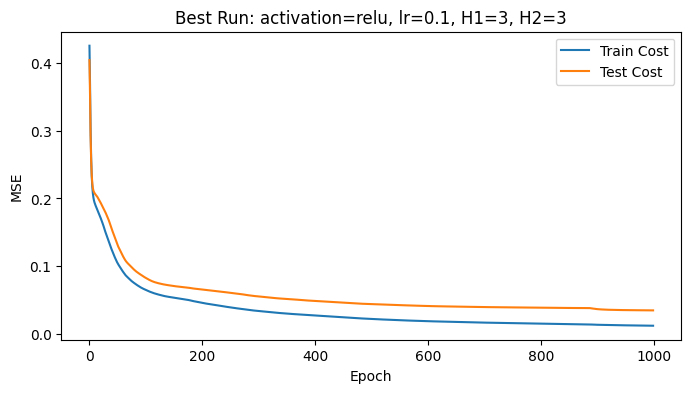

Train Accuracy: 0.9844
Test Accuracy: 0.975


In [43]:
# Plot the train and test cost curves for the best run
plt.figure(figsize=(8, 4))
plt.plot(best_run['train_curve'], label='Train Cost')
plt.plot(best_run['test_curve'], label='Test Cost')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title(f"Best Run: activation={best_run['activation']}, lr={best_run['learning_rate']}, H1={best_run['hidden_nodes_1']}, H2={best_run['hidden_nodes_2']}")
plt.legend()
plt.show()

# Print the train and test accuracy for the best run
print('Train Accuracy:', round(best_run['train_accuracy'], 4))
print('Test Accuracy:', round(best_run['test_accuracy'], 4))

## Part 5: Defend your best model

In this section, you should justify your final choice using evidence.

### Why this model is best
**Answer:** My best model is Run 2 with the relu activation, learning rate of 0.1, 3 nodes in each hidden layer, trained for 1000 epochs. I chose this model because it had the highest test accuracy out of all 6 runs at 0.9750, meaning it correctly predicted 97.5% of wines it had never seen before.

What really made me confident in this model though wasn’t just the accuracy number, but how consistent it looked across train and test results. The train accuracy was 0.9844 and the test accuracy was 0.9750, so the gap between them is only 0.0094. That’s really small, and it tells me the model isn’t just memorizing the training data but it’s actually learning the real pattern that separates red and white wine.

The learning curves also support this. Both train and test cost go down smoothly over time and stay close to each other without splitting apart. That’s a good sign because it means the model is improving in a balanced way instead of overfitting or behaving inconsistently.

### What evidence supports that choice
**Answer:** The choice of Run 2 is supported by everything I tested in Parts 3 and 4 together.

First, in Part 3, the activation results made it clear that ReLU was the strongest option. It reached about 0.9625 test accuracy, which was much higher than sigmoid (around 0.800) and slightly better than tanh. So that already pointed me toward ReLU as the best activation for this problem.

Then the learning rate experiment showed that 0.1 was the most reliable option. The higher learning rate (0.5) learned fast and got good results, but it felt more risky and less stable. The smaller learning rates (0.01 and 0.001) barely improved even after 500 epochs, so they were too slow to be useful.

In Part 4, Run 1 (ReLU, lr = 0.1, 500 epochs) already performed really well at 0.9625 test accuracy, but the cost curves were still clearly trending downward at epoch 500. That suggested the model hadn’t fully finished learning yet.

That’s what led to Run 2 when I kept everything the same but doubled the epochs to 1000. That change directly improved results with test accuracy increased from 0.9625 to 0.9750, and test cost also dropped from about 0.0441 to 0.0349. The curves still looked stable and didn’t start diverging, which shows the extra training time was actually useful instead of causing overfitting.

### What tradeoff I accepted
**Answer:** The main tradeoff I accepted with Run 2 was training time. Going from 500 to 1000 epochs almost doubled the runtime (about 10 seconds to around 19 seconds). That doesn’t sound huge here, but in larger real world datasets that kind of increase can matter a lot.

I accepted that cost because the improvement in accuracy was meaningful, and the model still stayed very stable. It didn’t start overfitting or become unstable even with the extra training time.

I also made a tradeoff in model size. I kept the hidden layers small (3 nodes each) instead of increasing them. From my earlier experiments, larger networks like 6 or 10 nodes didn’t actually improve test accuracy as they mostly just improved training performance and made the model more complex. So I chose simplicity over extra capacity, since it gave better generalization.

### Why another candidate was rejected
**Answer:** The strongest alternative was Run 6 ReLU, lr = 0.25, 6 nodes per layer, and 1000 epochs. It actually looks like a stronger model because it has more hidden nodes and still trains for the same number of epochs.

But even with that extra complexity, it only reached 0.9625 test accuracy, which is lower than Run 2’s 0.9750. At the same time, its training performance was better (very low training cost), which is actually a warning sign.

What that tells me is that Run 6 is fitting the training data extremely well, but that improvement isn’t transferring to unseen data. That’s a sign of overfitting so the model has extra capacity, and instead of improving general patterns, it starts learning noise or details specific to the training set.

Run 2, even though it’s simpler, is forced to focus on the most important patterns in the data. That constraint actually helps it generalize better, which is why it ends up performing better on the test set.

## Part 6: Comprehension questions

### Q1: What is the main difference between linear regression models and neural networks? Which pieces of the neural network make it more flexible?

**Answer:** Linear regression models can only learn straight line relationships between inputs and outputs. That means no matter what data you give it, it’s always trying to fit a linear pattern. So if the real relationship is curved or more complex, it can’t really capture that well.

Neural networks are more flexible because they add hidden layers and activation functions. The hidden layers let the model transform the input step by step instead of going straight from input to output. This allows it to build more complex patterns over multiple stages.

The activation functions (like ReLU, sigmoid, and tanh) are especially important because they introduce nonlinearity. Without them, the whole network would just collapse into something equivalent to a linear model no matter how many layers you add. The nonlinearity is what allows the model to learn curved and more complicated decision boundaries.

In this project, that flexibility is what allowed the model to reach high accuracy like 0.9750. A linear model would not be able to separate red and white wine that well because the relationship between the features is not purely linear.

### Q2: Why is tuning not the same thing as random guessing?

**Answer:** Tuning is not random guessing because every change is based on what you observed from previous results. You’re not just trying random values but you’re adjusting things based on evidence.

For example, I didn’t pick ReLU randomly. I chose it because earlier results showed it clearly performed better than sigmoid and slightly better than tanh. I also didn’t pick the learning rate randomly but I used 0.1 because it gave a stable learning curve compared to values that were either too fast or too slow.

Even the decision to go from 500 to 1000 epochs came from observing that the cost curve in Run 1 was still decreasing at epoch 500. That’s direct visual evidence that the model hadn’t fully converged yet.

So each decision builds off the previous experiment. That’s what makes it tuning because it’s guided by results, not guessing.

### Q3: Why can train accuracy and test accuracy tell different stories about model quality?

**Answer:** Train accuracy and test accuracy can tell different stories because they measure two different things. Train accuracy shows how well the model performs on data it has already seen. Test accuracy shows how well it performs on completely new data.

A model can get very high train accuracy just by memorizing the training examples instead of learning the actual pattern. But that doesn’t help when it sees new data.

In my results, Run 6 is a good example of this. It had very strong training performance (very low training cost), but it didn’t give the best test accuracy. Meanwhile Run 2 had slightly worse training fit but better test performance, which means it generalized better.

So test accuracy is usually the more important measure because it shows how the model would actually perform in the real world.

#### Q4: Did you notice a trade-off between training time and accuracy? Where or at what point?

**Answer:** Yes, I definitely saw a tradeoff between training time and accuracy.

The clearest example is between Run 1 and Run 2. Run 1 trained for 500 epochs and Run 2 trained for 1000. That almost doubled the training time, but it also improved test accuracy from 0.9625 to 0.9750. That shows that 500 epochs wasn’t enough and the extra training was actually useful.

But after that point, the tradeoff becomes less useful. Runs like 5 and 6 also used 1000 epochs, but they didn’t improve beyond Run 2. They just took longer without better results.

So there seems to be a point where more training helps, but after that you start hitting diminishing returns where extra time doesn’t improve accuracy and can even risk overfitting.

## Final model configuration dictionary

### Task
Report the exact final model configuration you want the grader to evaluate.

The grader will **retrain this exact model from scratch** using `seed = 42`.  
This makes grading more reliable than trusting whatever notebook state happens to be left in memory.

Leave the keys exactly as written and only edit the values if needed. Make sure the printed values in the cell below match your best run.
This is the model configuration the grader will evaluate.

If this dictionary is missing, malformed, or does not correspond to one of your 6 logged runs, the ranking component receives **0/10**.


In [44]:
#### DO NOT EDIT THE KEYS ####
final_model_config = {
    "activation": best_run["activation"],
    "learning_rate": best_run["learning_rate"],
    "epochs": best_run["epochs"],
    "hidden_nodes_1": best_run["hidden_nodes_1"],
    "hidden_nodes_2": best_run["hidden_nodes_2"]
}

final_model_config

{'activation': 'relu',
 'learning_rate': 0.1,
 'epochs': 1000,
 'hidden_nodes_1': 3,
 'hidden_nodes_2': 3}

## For TA grading purposes (leave in and do not touch)

This block serves two purposes:

1. It checks that the final configuration dictionary is in the required format and matches one of the logged runs.
2. It retrains the student's declared final model from scratch and reports visible-dataset and synthetic-dataset metrics.

In the full grading workflow, a **separate grader script** will handle batch processing across many student notebooks.  
This notebook block is mainly here to make the grading contract explicit and to give a local reference check.


In [45]:
#### DO NOT EDIT ####
def validate_final_config(final_model_config, logged_runs):
    required_keys = {"activation", "learning_rate", "epochs", "hidden_nodes_1", "hidden_nodes_2"}
    if not isinstance(final_model_config, dict):
        raise ValueError("final_model_config must be a dictionary.")
    if set(final_model_config.keys()) != required_keys:
        raise ValueError("final_model_config keys do not match the required format.")

    allowed = [
        {
            "activation": r["activation"],
            "learning_rate": r["learning_rate"],
            "epochs": r["epochs"],
            "hidden_nodes_1": r["hidden_nodes_1"],
            "hidden_nodes_2": r["hidden_nodes_2"],
        }
        for r in logged_runs
    ]

    if final_model_config not in allowed:
        raise ValueError("final_model_config must match one of the 6 logged runs.")

    return True

In [46]:
#### DO NOT EDIT ####
validate_final_config(final_model_config, logged_runs)

# Local paths for TA use
synth_x = pd.read_csv('synth_x.csv').to_numpy()
synth_y = pd.read_csv('synth_y.csv').to_numpy()

# Retrain the exact final model from the config dictionary
W1, W2, W3, b1, b2, b3 = GenerateAllWeights_2(
    input_nodes,
    final_model_config["hidden_nodes_1"],
    final_model_config["hidden_nodes_2"],
    output_nodes,
    seed
)

final_train_cost, final_test_cost = train_2(
    X_train,
    Y_train,
    X_test,
    Y_test,
    final_model_config["learning_rate"],
    final_model_config["epochs"],
    final_model_config["activation"]
)

final_train_acc = test_2(X_train, Y_train, final_model_config["activation"])
final_test_acc = test_2(X_test, Y_test, final_model_config["activation"])
final_synth_acc = test_2(synth_x, synth_y, final_model_config["activation"])

print("Final visible train MSE:", float(final_train_cost[-1]))
print("Final visible test MSE:", float(final_test_cost[-1]))
print("Final visible train accuracy:", round(final_train_acc, 4))
print("Final visible test accuracy:", round(final_test_acc, 4))
print("Final accuracy gap (train - test):", round(final_train_acc - final_test_acc, 4))
print("Final synthetic accuracy:", round(final_synth_acc, 4))

plt.figure(figsize=(11, 4.5))
plt.plot(final_train_cost, linewidth=2, label='Final Model Train Cost')
plt.plot(final_test_cost, linewidth=2, label='Final Model Test Cost')
plt.plot(baseline_result['test_curve'], '--', linewidth=2, label='Part 3 Baseline Test Cost')
plt.xlim(0, final_model_config["epochs"])
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('TA check: retrained final model vs Part 3 baseline')
plt.grid(alpha=0.25)
plt.legend()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'synth_x.csv'